In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[1]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/T1m>

In [18]:
ds1 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

ds1

<xarray.Dataset> Size: 340GB
Dimensions:                (time_counter: 420, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 3kB 1990-01-16T12:00...
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    evs                    (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfds                   (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 15GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    hfevapds               (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_bbl_li            (time_counter, deptht, y, x) float32 15GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ttrd_evd_li            (time_counter, deptht, y, x) float32 15GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ttrd_atf_li            (time_counter, deptht, y, x) float32 15GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 200MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 15GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>

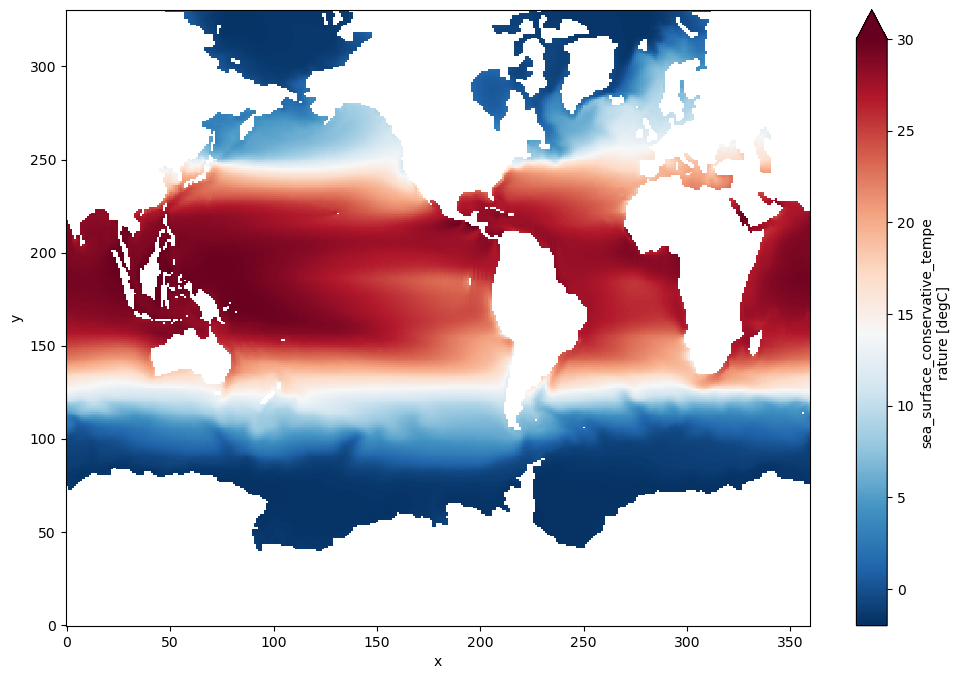

In [25]:
## Plotting with default method 

ds1['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r', figsize = (12,8), vmin = -2, vmax = 30)


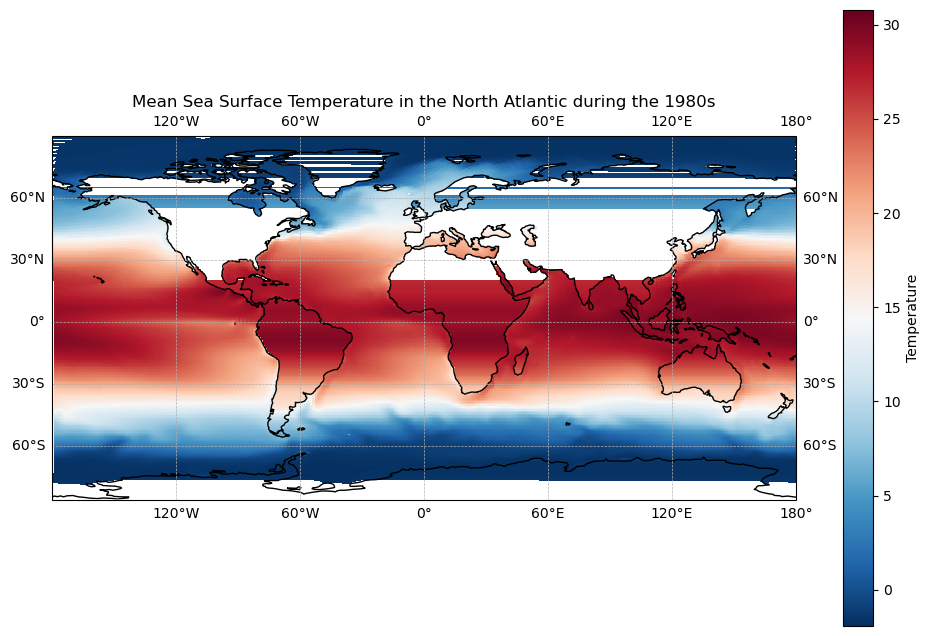

In [31]:
## Plotting North Atlantic using cartopy 

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

data = ds1['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds1['nav_lon'],  ds1['nav_lat'], data, cmap='RdBu_r', transform=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')

plt.colorbar(im, ax=ax, label='Temperature')
plt.show()

In [29]:
ds1['tos_con'].encoding.get('_FillValue')

1.0000000200408773e+20

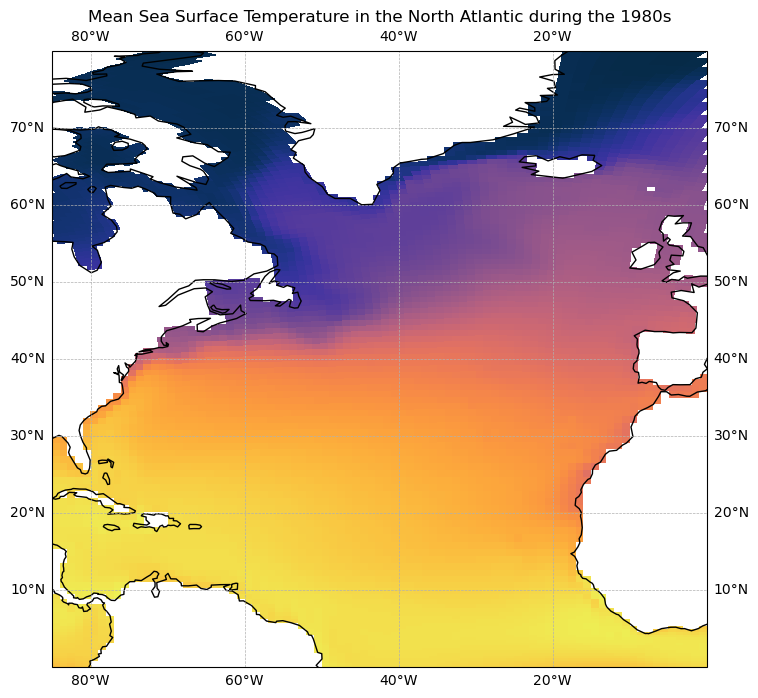

In [17]:
ds2 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12',
                          bbox = (-85.0, 0.0, 0.0, 80.0))

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds2['tos_con'].mean(dim='time_counter')
im = ax.pcolormesh(ds2['nav_lon'],  ds2['nav_lat'], data, cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree(), vmin = -3, vmax = 30)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.set_title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())

plt.show()

In [16]:
print("data.shape:", data.shape)
print("nav_lon.shape:", ds1['nav_lon'].shape)
print("nav_lat.shape:", ds1['nav_lat'].shape)
print("lon min/max:", ds1['nav_lon'].min().values, ds1['nav_lon'].max().values)
print("lat min/max:", ds1['nav_lat'].min().values, ds1['nav_lat'].max().values)

data.shape: (331, 360)
nav_lon.shape: (331, 360)
nav_lat.shape: (331, 360)
lon min/max: -179.99653278676575 179.99031297181477
lat min/max: -85.78874492732504 89.7417689202141


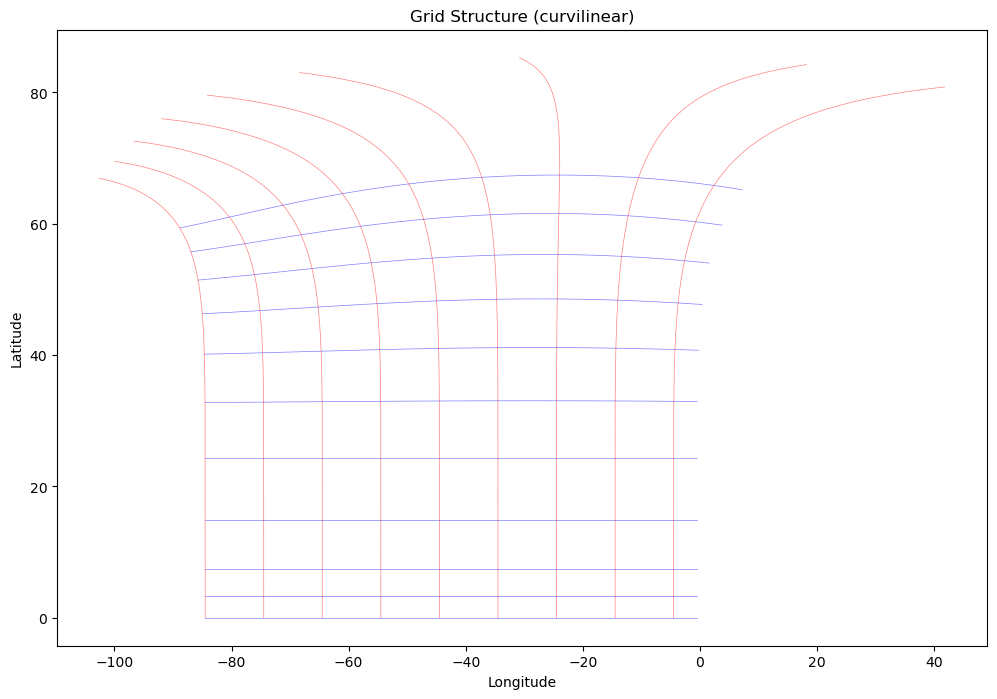

In [15]:
#### What does a Curvilinear grid look like?

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(0, 106, 10):
    ax.plot(ds2['nav_lon'][i, :], ds2['nav_lat'][i, :], 'b-', alpha=0.5, linewidth=0.5)
    
for j in range(0, 90, 10):
    ax.plot(ds2['nav_lon'][:, j], ds2['nav_lat'][:, j], 'r-', alpha=0.5, linewidth=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Grid Structure (curvilinear)')
plt.show()